In [2]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [3]:

load_dotenv()

True

In [4]:
model=ChatOpenAI(model='gpt-4o-mini')

In [5]:
model.invoke("write essay about nepal in english about 1000 words and show me the output :Then transalte into nepali and show me the output ,then transalate into protugese and show me the output,then explain 3 of them and also write summary and also improvement suggestion").content

"### Essay: Nepal - A Nation of Diversity and Resilience\n\n#### Introduction\n\nNepal, a landlocked country nestled in the heart of the Himalayas, is renowned for its breathtaking landscapes, rich cultural heritage, and diverse population. Bordered by India to the south and China to the north, Nepal boasts an impressive array of natural wonders, including eight of the fourteen highest peaks in the world, including the majestic Mount Everest. This essay explores the geographical features, cultural richness, and historical significance of Nepal, emphasizing its resilience in the face of challenges.\n\n#### Geographical Features\n\nNepal's geographical diversity is astonishing. The country's terrain ranges from the lowland Terai plains to the towering peaks of the Himalayas, creating a unique ecosystem filled with distinct flora and fauna. The Terai region, characterized by its flat plains and agricultural productivity, contrasts sharply with the rugged terrain of the Himalayan region, w

In [6]:
prompt = """
Write a detailed essay about Nepal in English of about 1,000 words. 
After the essay, follow these exact steps in order, using plain text dividers (like dashes or capital letters) instead of markdown symbols like hashes or bold tags:

1. English Essay: Write the essay with standard paragraph breaks. Do not use bold text or markdown headings. Use plain text section titles written in ALL CAPS.
2. Nepali Translation: Translate the entire English essay into fluent Nepali using plain text and capital letters for section titles.
3. Portuguese Translation: Translate the entire English essay into fluent Portuguese using plain text and capital letters for section titles.
4. Explanation: Explain the three versions in plain text.
5. Summary: Provide a summary in plain text.
6. Improvement Suggestions: Provide improvement suggestions in plain text.

CRITICAL INSTRUCTIONS: Do not use any asterisks(*) and (**) for bolding, and do not use hash(#)and (###) symbols for headings. Use standard text formatting only.
"""

response = model.invoke(prompt)



In [7]:
print(response)

content='NEPAL: A LAND OF DIVERSITY AND BEAUTY\n\nNepal, a landlocked country situated in South Asia, is renowned for its stunning landscapes, rich cultural heritage, and diverse population. Bordered by China to the north and India to the south, east, and west, Nepal sits within the majestic Himalayas, home to some of the world’s tallest peaks, including Mount Everest, the highest point on Earth. This geographical setting endows Nepal with breathtaking scenery, ranging from the lowland Terai plains to the towering Himalayan ranges, making it a unique destination for trekkers, adventurers, and nature lovers.\n\nThe cultural landscape of Nepal is as diverse as its geography. The country is home to over 120 ethnic groups and more than 120 languages, which reflect a multitude of traditions, beliefs, and practices. The major religions practiced in Nepal include Hinduism, Buddhism, and Islam, which influence the daily lives of the people. Hinduism is the predominant religion, and it shapes v

In [8]:
print(response.content)

NEPAL: A LAND OF DIVERSITY AND BEAUTY

Nepal, a landlocked country situated in South Asia, is renowned for its stunning landscapes, rich cultural heritage, and diverse population. Bordered by China to the north and India to the south, east, and west, Nepal sits within the majestic Himalayas, home to some of the world’s tallest peaks, including Mount Everest, the highest point on Earth. This geographical setting endows Nepal with breathtaking scenery, ranging from the lowland Terai plains to the towering Himalayan ranges, making it a unique destination for trekkers, adventurers, and nature lovers.

The cultural landscape of Nepal is as diverse as its geography. The country is home to over 120 ethnic groups and more than 120 languages, which reflect a multitude of traditions, beliefs, and practices. The major religions practiced in Nepal include Hinduism, Buddhism, and Islam, which influence the daily lives of the people. Hinduism is the predominant religion, and it shapes various aspect

In [9]:
MAX_TOKENS=150

In [10]:

def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [11]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [12]:

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

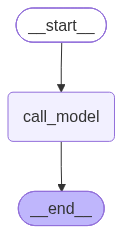

In [13]:

graph

In [14]:

config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Samrat."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Samrat.


'Hi Samrat! How can I assist you today?'

In [15]:

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 38
Hi, my name is Samrat.
Hi Samrat! How can I assist you today?
Can you explain short term memory?


"Short-term memory (STM) is a part of the memory system that temporarily holds and processes information for a brief period, typically ranging from about 15 to 30 seconds. It allows us to retain small amounts of information for immediate use, such as recalling a phone number long enough to dial it or remembering a few words from a sentence.\n\nHere are some key characteristics of short-term memory:\n\n1. **Capacity**: Short-term memory has a limited capacity, often cited as about 7±2 items (a concept known as Miller's Law). This means most people can hold about 5 to 9 pieces of information simultaneously.\n\n2. **Duration**: Information in short-term memory can last for a short duration. If not actively rehearsed or encoded into long-term memory, it may be lost within seconds to a minute.\n\n3. **Type of Information**: Short-term memory can store various types of information, such as numbers, letters, or words. However, the type of information is often better retained if it is organize

In [16]:

result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


"I'm sorry, but I don't know your name. How can I assist you today?"

In [17]:

for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Samrat.
------------------------------------------------------------------------------------------------------------------------
Hi Samrat! How can I assist you today?
------------------------------------------------------------------------------------------------------------------------
Can you explain short term memory?
------------------------------------------------------------------------------------------------------------------------
Short-term memory (STM) is a part of the memory system that temporarily holds and processes information for a brief period, typically ranging from about 15 to 30 seconds. It allows us to retain small amounts of information for immediate use, such as recalling a phone number long enough to dial it or remembering a few words from a sentence.

Here are some key characteristics of short-term memory:

1. **Capacity**: Short-term memory has a limited capacity, often cited as about 7±2 items (a concept known as Miller's Law). This means most